In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('faceit_matches.csv')
df.head()

,match_id,collected_at,map,t1_avg_elo,t1_elo_std,t1_min_elo,t1_max_elo,t1_avg_kd,t1_avg_hs_pct,t1_avg_win_rate,...,t2_avg_win_rate,t2_avg_matches,t2_avg_level,t2_avg_form,elo_diff,kd_diff,wr_diff,score_t1,score_t2,team1_win
0,1-169c7c63-7622-4c71-91b3-a7f7f4979d9e,2026-03-16T16:30:58.706670+00:00,de_nuke,2879.8,196.04,2686.0,3194.0,1.086,46.4,52.0,...,56.2,3084.8,9.8,0.52,22.8,-0.112,-4.2,16.0,14.0,1
1,1-e0880183-2880-4285-aa8d-f41b4af817c3,2026-03-16T16:31:09.469225+00:00,de_dust2,2818.6,404.15,2211.0,3303.0,1.206,48.8,53.8,...,55.8,3866.4,9.8,0.52,-74.6,-0.008,-2.0,11.0,13.0,0
2,1-85267fa4-9dcd-4598-9a7e-6569b70c87d2,2026-03-16T16:31:35.987438+00:00,de_nuke,2688.2,340.72,2197.0,3156.0,1.086,44.8,51.0,...,52.0,4007.4,10.0,0.80,-191.6,0.000,-1.0,8.0,13.0,0
3,1-96ec0c2c-4af5-4e45-a9b8-4ba16050eb9c,2026-03-16T16:31:43.755863+00:00,de_anubis,2750.2,251.65,2488.0,3039.0,1.120,48.4,51.2,...,51.6,3733.6,10.0,0.72,-7.0,0.048,-0.4,7.0,13.0,0
4,1-7a6a3cab-0bf9-46af-a68c-833635b1cb9c,2026-03-16T16:31:57.285271+00:00,de_dust2,2675.2,135.24,2496.0,2805.0,1.176,44.4,52.4,...,52.4,5789.6,10.0,0.60,-136.8,-0.018,0.0,17.0,19.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         10000 non-null  object 
 1   collected_at     10000 non-null  object 
 2   map              10000 non-null  object 
 3   t1_avg_elo       10000 non-null  float64
 4   t1_elo_std       10000 non-null  float64
 5   t1_min_elo       10000 non-null  float64
 6   t1_max_elo       10000 non-null  float64
 7   t1_avg_kd        10000 non-null  float64
 8   t1_avg_hs_pct    10000 non-null  float64
 9   t1_avg_win_rate  10000 non-null  float64
 10  t1_avg_matches   10000 non-null  float64
 11  t1_avg_level     10000 non-null  float64
 12  t1_avg_form      10000 non-null  float64
 13  t2_avg_elo       10000 non-null  float64
 14  t2_elo_std       10000 non-null  float64
 15  t2_min_elo       10000 non-null  float64
 16  t2_max_elo       10000 non-null  float64
 17  t2_avg_kd    

In [ ]:
df.describe().round(2)

,t1_avg_elo,t1_elo_std,t1_min_elo,t1_max_elo,t1_avg_kd,t1_avg_hs_pct,t1_avg_win_rate,t1_avg_matches,t1_avg_level,t1_avg_form,...,t2_avg_win_rate,t2_avg_matches,t2_avg_level,t2_avg_form,elo_diff,kd_diff,wr_diff,score_t1,score_t2,team1_win
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,1926.11,185.34,1699.79,2157.81,1.10,46.90,50.94,1592.90,8.21,0.51,...,50.97,1598.77,8.19,0.51,4.06,0.00,-0.02,10.89,10.87,0.51
std,631.79,113.59,637.50,671.18,0.08,3.56,2.84,1303.52,2.15,0.14,...,2.91,1311.15,2.16,0.15,69.78,0.08,3.04,3.75,3.72,0.50
min,402.20,10.92,0.00,480.00,0.59,32.60,9.40,0.00,1.00,0.00,...,15.60,0.00,1.00,0.00,-468.80,-0.47,-41.40,0.00,0.00,0.00
25%,1445.10,108.30,1207.00,1667.00,1.06,44.60,50.00,625.00,7.00,0.40,...,50.00,619.95,7.00,0.40,-48.45,-0.04,-1.00,8.00,8.00,0.00
50%,1926.10,152.75,1708.00,2166.00,1.10,47.00,51.00,1289.90,9.20,0.52,...,51.00,1290.90,9.20,0.52,6.20,0.00,0.00,13.00,13.00,1.00
75%,2375.80,235.68,2155.00,2600.00,1.14,49.40,52.00,2177.60,10.00,0.60,...,52.00,2205.35,10.00,0.60,55.80,0.04,1.00,13.00,13.00,1.00
max,3974.20,1061.74,3569.00,5024.00,2.65,58.40,69.00,10777.00,10.00,1.00,...,81.40,9583.40,10.00,1.00,689.60,1.47,28.60,28.00,28.00,1.00


# Data quality checks

null values

In [2]:
missing = df.isnull().sum()
print(missing)

match_id           0
collected_at       0
map                0
t1_avg_elo         0
t1_elo_std         0
t1_min_elo         0
t1_max_elo         0
t1_avg_kd          0
t1_avg_hs_pct      0
t1_avg_win_rate    0
t1_avg_matches     0
t1_avg_level       0
t1_avg_form        0
t2_avg_elo         0
t2_elo_std         0
t2_min_elo         0
t2_max_elo         0
t2_avg_kd          0
t2_avg_hs_pct      0
t2_avg_win_rate    0
t2_avg_matches     0
t2_avg_level       0
t2_avg_form        0
elo_diff           0
kd_diff            0
wr_diff            0
score_t1           0
score_t2           0
team1_win          0
dtype: int64


duplicates

In [4]:
dupes = df['match_id'].duplicated().sum()
print(dupes)

0


zero ELO check. 0 means that the data could not been fetched

In [5]:
zero_elo_t1 = (df['t1_avg_elo'] == 0).sum()
zero_elo_t2 = (df['t2_avg_elo'] == 0).sum()
print(zero_elo_t1)
print(zero_elo_t2)

0
0


# Graphs showing how wins are distributed

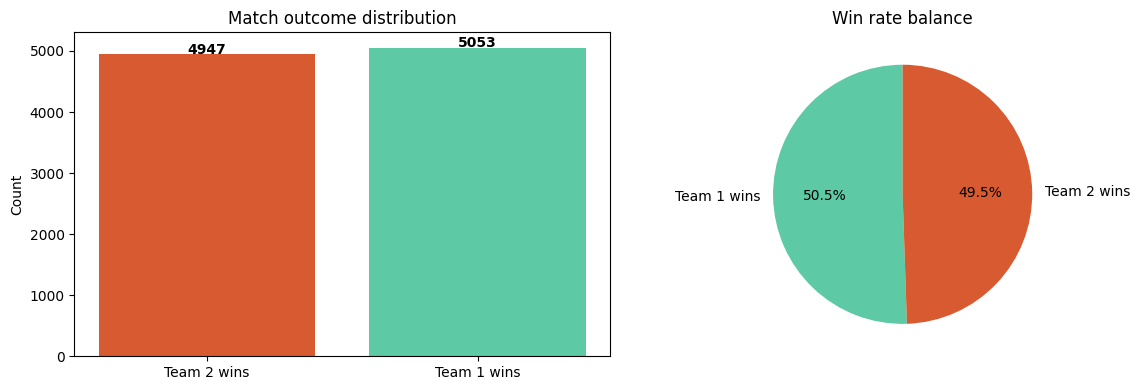

Team 1 win rate: 50.53%
Team 2 win rate: 49.47%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['team1_win'].value_counts()
colors = ['#D85A30', '#5DCAA5']

axes[0].bar(['Team 2 wins', 'Team 1 wins'], [counts[0], counts[1]], color=colors)
axes[0].set_title('Match outcome distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie([counts[1], counts[0]], labels=['Team 1 wins', 'Team 2 wins'],autopct='%1.1f%%', colors=colors[::-1], startangle=90)
axes[1].set_title('Win rate balance')

plt.tight_layout()
plt.show()

print(f'Team 1 win rate: {df["team1_win"].mean():.2%}')
print(f'Team 2 win rate: {1 - df["team1_win"].mean():.2%}')


# Team average ELO

team 1

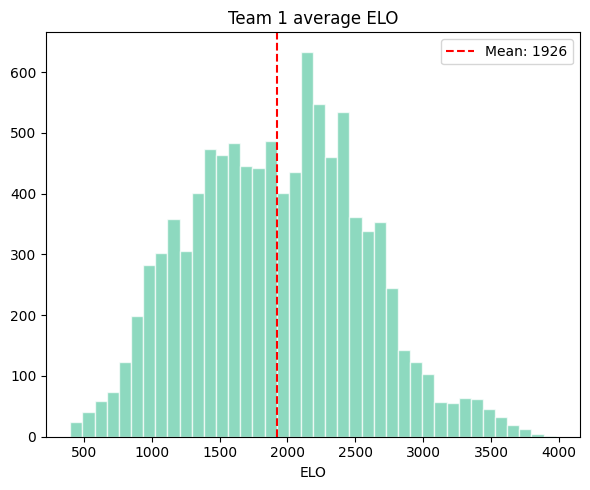

ELO range: 402 - 3974


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df['t1_avg_elo'], bins=40, color='#5DCAA5', alpha=0.7, edgecolor='white')
ax.axvline(df['t1_avg_elo'].mean(), color='red', linestyle='--',label=f'Mean: {df["t1_avg_elo"].mean():.0f}')
ax.set_title('Team 1 average ELO')
ax.set_xlabel('ELO')
ax.legend()

plt.tight_layout()
plt.show()

print(f'ELO range: {df["t1_avg_elo"].min():.0f} - {df["t1_avg_elo"].max():.0f}')


team 2

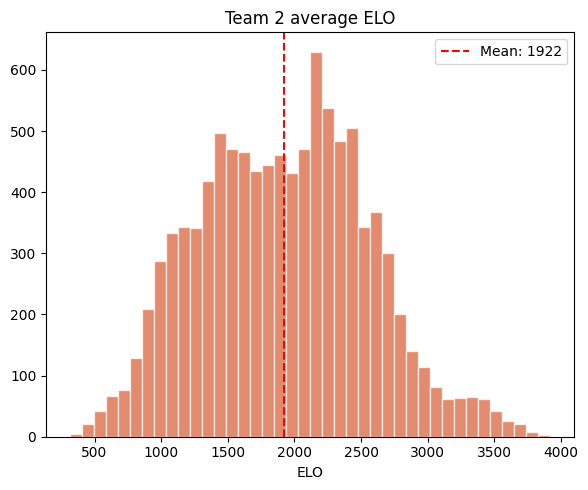

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df['t2_avg_elo'], bins=40, color='#D85A30', alpha=0.7, edgecolor='white')
ax.axvline(df['t2_avg_elo'].mean(), color='red', linestyle='--',label=f'Mean: {df["t2_avg_elo"].mean():.0f}')
ax.set_title('Team 2 average ELO')
ax.set_xlabel('ELO')
ax.legend()

plt.tight_layout()
plt.show()


difference between ELO between both teams againt each other

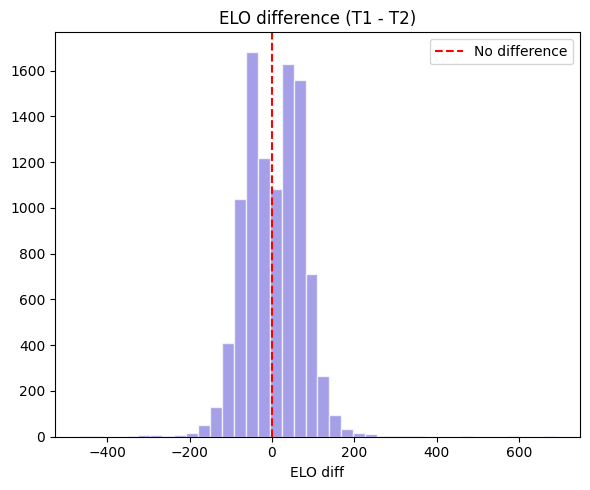

Mean ELO diff: 4.1 (close to 0 = matchmaking is balanced)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df['elo_diff'], bins=40, color='#7F77DD', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='No difference')
ax.set_title('ELO difference (T1 - T2)')
ax.set_xlabel('ELO diff')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Mean ELO diff: {df["elo_diff"].mean():.1f} (close to 0 = matchmaking is balanced)')


# Graph showing how matches are distributed between maps

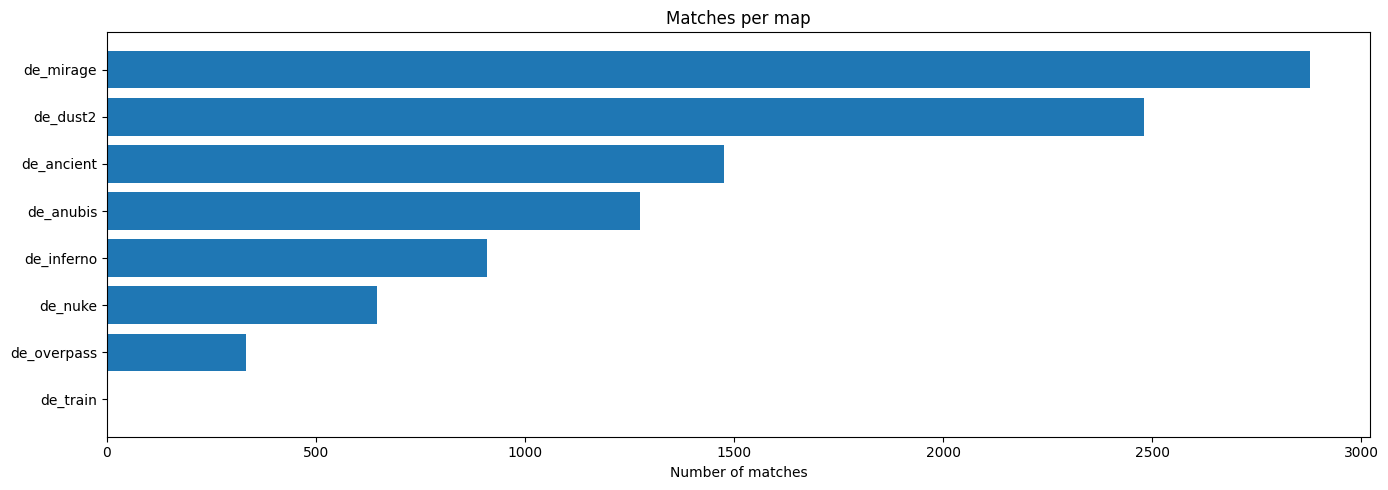

In [ ]:
fig, axes = plt.subplots( figsize=(14, 5))

map_counts = df['map'].value_counts()
axes.barh(map_counts.index[::-1], map_counts.values[::-1])
axes.set_title('Matches per map')
axes.set_xlabel('Number of matches')


plt.tight_layout()
plt.show()

# Heatmap showing what data correlate the most ? to the team1 win

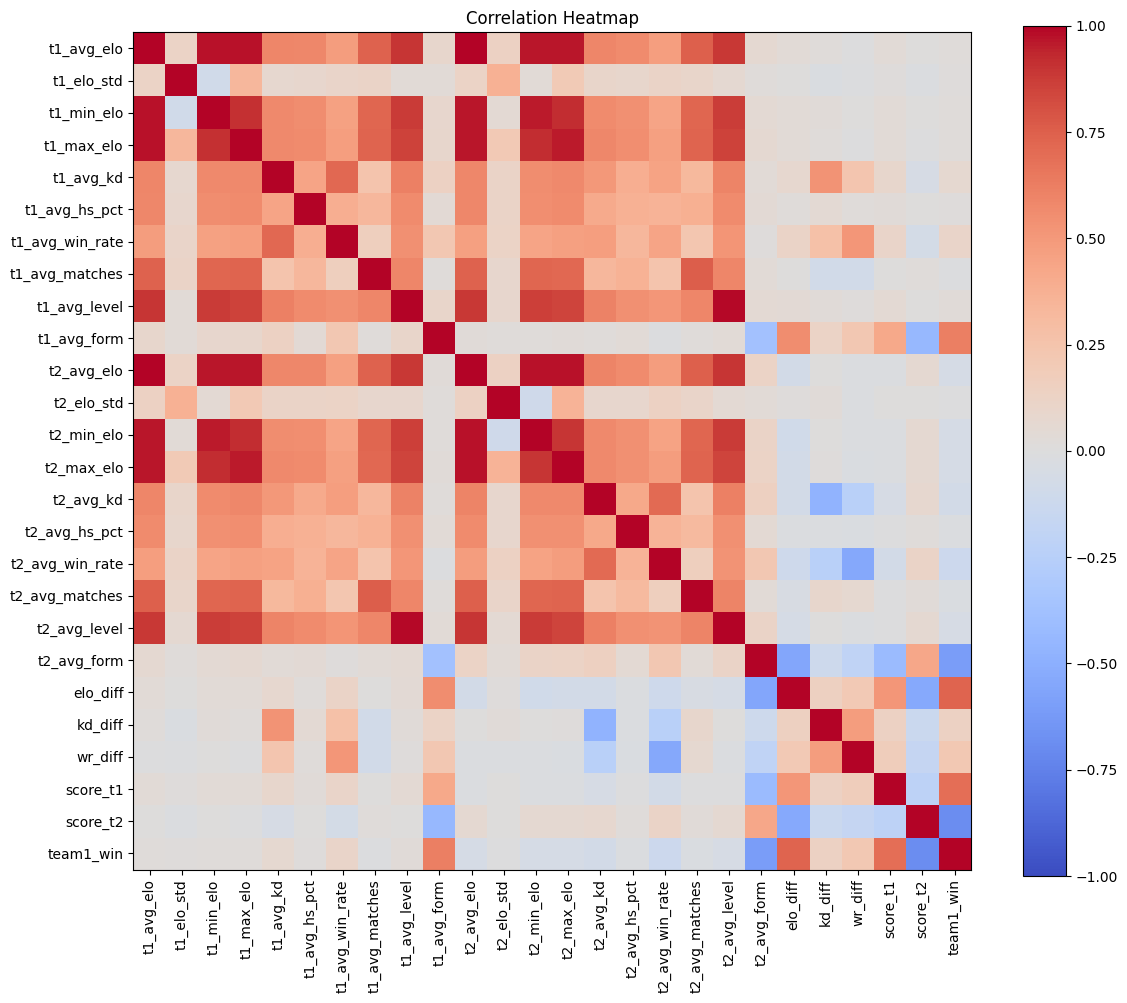

In [ ]:

numeric_cols = df.select_dtypes(include=[np.number]).columns

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(cax, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# Fixing ELO to pre-match values

In [6]:
df_copy = df.copy()
K = 50

def reverse_elo(row, iterations=5):
    t1_post = row['t1_avg_elo']
    t2_post = row['t2_avg_elo']

    t1_pre = t1_post
    t2_pre = t2_post

    for _ in range(iterations):
        E = 1 / (1 + 10 ** ((t2_pre - t1_pre) / 400))

        if row['team1_win'] == 1:
            t1_pre = t1_post - K * (1 - E)
            t2_pre = t2_post + K * E
        else:
            t1_pre = t1_post + K * E
            t2_pre = t2_post - K * (1 - E)

    return pd.Series({'t1_avg_elo_pre': t1_pre, 't2_avg_elo_pre': t2_pre})

In [7]:
fixed_elo = df.apply(reverse_elo, axis=1)

In [8]:
df['t1_avg_elo'] = fixed_elo['t1_avg_elo_pre']
df['t2_avg_elo'] = fixed_elo['t2_avg_elo_pre']

df['elo_diff'] = df['t1_avg_elo'] - df['t2_avg_elo']

elo_shift_t1 = df['t1_avg_elo'] - df_copy['t1_avg_elo']
elo_shift_t2 = df['t2_avg_elo'] - df_copy['t2_avg_elo']
df['t1_min_elo'] = df_copy['t1_min_elo'] + elo_shift_t1
df['t1_max_elo'] = df_copy['t1_max_elo'] + elo_shift_t1
df['t2_min_elo'] = df_copy['t2_min_elo'] + elo_shift_t2
df['t2_max_elo'] = df_copy['t2_max_elo'] + elo_shift_t2


Dropping features that came out to be bad

In [9]:
form_cols = ['t1_avg_form', 't2_avg_form']
df = df.drop(columns=form_cols)

# Data cleaning

Created a score_diff feature for regression

In [10]:
df['score_diff'] = df['score_t1'] - df['score_t2']


dropping feautures that we dont need

In [11]:
drop_cols = ['match_id', 'collected_at', 'score_t1', 'score_t2']
df = df.drop(columns=drop_cols)

creating new features that capture realtionships between team statistics

In [12]:
df['elo_ratio'] = df['t1_avg_elo'] / df['t2_avg_elo']
df['kd_ratio'] = df['t1_avg_kd'] / df['t2_avg_kd']
df['experience_ratio'] = df['t1_avg_matches'] / df['t2_avg_matches'].clip(lower=1)

df['elo_total'] = df['t1_avg_elo'] + df['t2_avg_elo']

df['elo_spread_diff'] = df['t1_elo_std'] - df['t2_elo_std']
df['hs_diff'] = df['t1_avg_hs_pct'] - df['t2_avg_hs_pct']
df['level_diff'] = df['t1_avg_level'] - df['t2_avg_level']

df['t1_consistency'] = 1 / (1 + df['t1_elo_std'])
df['t2_consistency'] = 1 / (1 + df['t2_elo_std'])

print('New features created:')
new_features = ['elo_ratio', 'kd_ratio', 'experience_ratio', 'elo_total',
                'elo_spread_diff', 'hs_diff', 'level_diff',
                't1_consistency', 't2_consistency']
for f in new_features:
    print(f'  {f}: min={df[f].min():.3f}, mean={df[f].mean():.3f}, max={df[f].max():.3f}')

print(f'\nTotal features after engineering: {len(df.columns) - 1} (+ target)')

New features created:
  elo_ratio: min=0.745, mean=1.003, max=2.416
  kd_ratio: min=0.579, mean=1.003, max=2.242
  experience_ratio: min=0.000, mean=1.861, max=3811.200
  elo_total: min=723.905, mean=3848.661, max=7869.106
  elo_spread_diff: min=-909.850, mean=-10.494, max=694.570
  hs_diff: min=-18.400, mean=-0.015, max=19.800
  level_diff: min=-1.800, mean=0.024, max=1.800
  t1_consistency: min=0.001, mean=0.007, max=0.084
  t2_consistency: min=0.001, mean=0.007, max=0.156

Total features after engineering: 32 (+ target)


Reworking the dataset removing features

In [13]:
df['experience_ratio'] = (df['t1_avg_matches'] / df['t2_avg_matches'].clip(lower=1)).clip(upper=5)
df['elo_total'] = df['t1_avg_elo'] + df['t2_avg_elo']
df['hs_diff'] = df['t1_avg_hs_pct'] - df['t2_avg_hs_pct']
df['level_diff'] = df['t1_avg_level'] - df['t2_avg_level']

keep_cols = [
    'elo_diff', 'kd_diff', 'wr_diff', 'hs_diff', 'level_diff',
    'elo_total', 'experience_ratio', 'map',
    'team1_win', 'score_diff'
]

df = df[[c for c in keep_cols if c in df.columns]]

# saving dataset and export

In [14]:
df.to_csv('faceit_clean.csv', index=False)